# Dataset Download and Imports

In [ ]:
!wget https://raw.githubusercontent.com/aboguszewski/wum_assignment/refs/heads/main/assignment2.csv -O assignment2.csv

--2025-05-30 23:47:55--  https://raw.githubusercontent.com/aboguszewski/wum_assignment/refs/heads/main/assignment2.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14570578 (14M) [text/plain]
Saving to: ‘assignment2.csv’

assignment2.csv     100%[===================>]  13.90M  --.-KB/s    in 0.1s    

2025-05-30 23:47:56 (101 MB/s) - ‘assignment2.csv’ saved [14570578/14570578]



In [ ]:
RANDOM_SEED = 42

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import precision_score, recall_score, confusion_matrix, f1_score
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

In [ ]:
data = pd.read_csv('assignment2.csv', sep=';')

# Baseline Models

## Regression

In [ ]:
# No preprocessing apart from dropping 'Class'
regression_data = data.drop('Class', axis=1)

training_X = regression_data.drop('Output', axis=1)
training_y = regression_data['Output']

# Fitting the model
linear_regression = LinearRegression(fit_intercept=True)
linear_regression.fit(X=training_X, y=training_y)

# Training metrics
def rmse(model, X, y):
  return np.sqrt(np.mean((model.predict(X=X) - y)**2))

training_r2 = linear_regression.score(X=training_X, y=training_y)
training_rmse = rmse(linear_regression, training_X, training_y)

# Cross-validation metrics
cross_validation = KFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)
cross_validation_r2 = []
cross_validation_rmse = []

for (training_indexes, test_indexes) in cross_validation.split(X=training_X, y=training_y):
  fold_training_X = training_X.iloc[training_indexes]
  fold_training_y = training_y.iloc[training_indexes]

  linear_regression.fit(X=fold_training_X, y=fold_training_y)

  fold_test_X = training_X.iloc[test_indexes]
  fold_test_y = training_y.iloc[test_indexes]

  cross_validation_r2.append(
      linear_regression.score(X=fold_test_X, y=fold_test_y)
  )

  cross_validation_rmse.append(
      rmse(linear_regression, fold_test_X, fold_test_y)
  )

print('-- Training Scores --')
print(f'R^2: {training_r2:.2f}')
print(f'RMSE: {training_rmse:.2f}\n')

print('-- Cross-Validation Scores --')
print(f'R^2: mean= {np.mean(cross_validation_r2):.2f}, std= {np.std(cross_validation_r2):.2f}')
print(f'RMSE: mean= {np.mean(cross_validation_rmse):.2f}, std= {np.std(cross_validation_rmse):.2f}\n')

print('-- Output Statistics --')
print(training_y.describe())

-- Training Scores --
R^2: 0.61
RMSE: 2.23

-- Cross-Validation Scores --
R^2: mean= 0.38, std= 0.11
RMSE: mean= 2.78, std= 0.15

-- Output Statistics --
count    2000.000000
mean        0.106647
std         3.562855
min       -12.384019
25%        -2.310265
50%         0.140658
75%         2.435991
max        11.676146
Name: Output, dtype: float64


- On the training data, the model's score is decent in the R^2 metric, however the RMSE isn't the best. I would say that it is quite close to the standard deviation of the "Output" so it's performance isn't that much better than just guessing the average.  
- Cross-validation shows the model's flaws even further. The R^2 plummeted to a less than acceptable level. The RMSE also increased, which makes the test performance estimates even closer to a simple "guess the mean" model.

## Classification

In [ ]:
# No preprocessing apart from dropping 'Output'
classification_data = data.drop('Output', axis=1)

training_X = classification_data.drop('Class', axis=1)
training_y = classification_data['Class']

# Fitting the model
logistic_regression = LogisticRegression(fit_intercept=True, penalty=None, solver='lbfgs', random_state=RANDOM_SEED)
logistic_regression.fit(X=training_X, y=training_y)

# Training metrics
y_prediction = logistic_regression.predict(X=training_X)

training_f_score = f1_score(training_y, y_prediction)
training_precision = precision_score(training_y, y_prediction)
training_recall = recall_score(training_y, y_prediction)
training_confusion_matrix = confusion_matrix(training_y, y_prediction)

# Cross-validation metrics
cross_validation = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)
cross_validation_f_score = []
cross_validation_precision = []
cross_validation_recall = []
cross_validation_TP = []
cross_validation_TN = []
cross_validation_FP = []
cross_validation_FN = []

for (training_indexes, test_indexes) in cross_validation.split(X=training_X, y=training_y):
  fold_training_X = training_X.iloc[training_indexes]
  fold_training_y = training_y.iloc[training_indexes]

  logistic_regression.fit(X=fold_training_X, y=fold_training_y)

  fold_test_X = training_X.iloc[test_indexes]
  fold_test_y = training_y.iloc[test_indexes]

  y_prediction = logistic_regression.predict(X=fold_test_X)

  cross_validation_f_score.append(
      f1_score(y_true=fold_test_y, y_pred=y_prediction)
  )

  cross_validation_precision.append(
      precision_score(fold_test_y, y_prediction)
  )

  cross_validation_recall.append(
      recall_score(fold_test_y, y_prediction)
  )

  cross_validation_confusion_matrix = confusion_matrix(fold_test_y, y_prediction)
  cross_validation_TP.append(cross_validation_confusion_matrix[0][0]/len(fold_test_y))
  cross_validation_TN.append(cross_validation_confusion_matrix[1][1]/len(fold_test_y))
  cross_validation_FP.append(cross_validation_confusion_matrix[0][1]/len(fold_test_y))
  cross_validation_FN.append(cross_validation_confusion_matrix[1][0]/len(fold_test_y))

print('-- Training Scores --')
print(f'F-score: {training_f_score:.2f}')
print(f'Precision: {training_precision:.2f}')
print(f'Recall: {training_recall:.2f}')
print(f'True Positives: {training_confusion_matrix[0][0]/len(training_y):.2f}, True Negatives: {training_confusion_matrix[1][1]/len(training_y):.2f}')
print(f'False Positives: {training_confusion_matrix[0][1]/len(training_y):.2f}, False Negatives: {training_confusion_matrix[1][0]/len(training_y):.2f}\n')

print('-- Cross-Validation Scores --')
print(f'F-score: mean= {np.mean(cross_validation_f_score):.2f}, std= {np.std(cross_validation_f_score):.2f}')
print(f'Precision: mean= {np.mean(cross_validation_precision):.2f}, std= {np.std(cross_validation_precision):.2f}')
print(f'Recall: mean= {np.mean(cross_validation_recall):.2f}, std= {np.std(cross_validation_recall):.2f}')
print(f'True Positives: mean= {np.mean(cross_validation_TP):.2f}, std= {np.std(cross_validation_TP):.2f}')
print(f'True Negatives: mean= {np.mean(cross_validation_TN):.2f}, std= {np.std(cross_validation_TN):.2f}')
print(f'False Positives: mean= {np.mean(cross_validation_FP):.2f}, std= {np.std(cross_validation_FP):.2f}')
print(f'False Negatives: mean= {np.mean(cross_validation_FN):.2f}, std= {np.std(cross_validation_FN):.2f}\n')

print('-- Class Distribution --')
print(data['Class'].value_counts())

-- Training Scores --
F-score: 0.72
Precision: 0.71
Recall: 0.72
True Positives: 0.35, True Negatives: 0.36
False Positives: 0.15, False Negatives: 0.14

-- Cross-Validation Scores --
F-score: mean= 0.54, std= 0.03
Precision: mean= 0.54, std= 0.03
Recall: mean= 0.54, std= 0.04
True Positives: mean= 0.26, std= 0.01
True Negatives: mean= 0.27, std= 0.02
False Positives: mean= 0.23, std= 0.01
False Negatives: mean= 0.23, std= 0.02

-- Class Distribution --
Class
1    1013
0     987
Name: count, dtype: int64


- For the training data the model scores quite well. Precison and recall are both ok. There doesn't seem to be any bias towards either the positive or negative class based on the confusion matrix.
- As before, cross-validation shows that the model is much worse than the training metrics suggest. Now the model is not significantly better than a coin toss. However it still doesn't seem to be biased towards any class.
- The confusion matrix elements are displayed with their proper names, assuming class 1 is the positive one. They are in range [0,1], because it's a ratio.


# More Advanced Classification

## Logistic Regression with Lasso

In [ ]:
# First let's try no preprocessing and let the lasso choose the important predictors
classification_data = data.drop('Output', axis=1)

training_X = classification_data.drop('Class', axis=1)
training_y = classification_data['Class']

# Use cross-validation to test different regularization parameters
regularization_parameters = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]

parameter_f_score = {}
for regularization_parameter in regularization_parameters:
  cross_validation = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)
  f_scores = []

  for (training_indexes, test_indexes) in cross_validation.split(X=training_X, y=training_y):
    fold_training_X = training_X.iloc[training_indexes]
    fold_training_y = training_y.iloc[training_indexes]

    lasso_regression = LogisticRegression(fit_intercept=True, penalty='l1', solver='liblinear', C=regularization_parameter, random_state=RANDOM_SEED)
    lasso_regression.fit(X=fold_training_X, y=fold_training_y)

    fold_test_X = training_X.iloc[test_indexes]
    fold_test_y = training_y.iloc[test_indexes]

    fold_y_prediction = lasso_regression.predict(X=fold_test_X)

    f_scores.append(f1_score(y_true=fold_test_y, y_pred=fold_y_prediction))

  parameter_f_score[regularization_parameter] = (np.mean(f_scores), np.std(f_scores))

print('-- F-Scores for Different Regularization Parameters --')
for regularization_parameter in regularization_parameters:
  print(f'C= {regularization_parameter}: mean= {parameter_f_score[regularization_parameter][0]:.2f}, std= {parameter_f_score[regularization_parameter][1]:.2f}')

-- F-Scores for Different Regularization Parameters --
C= 0.001: mean= 0.00, std= 0.00
C= 0.005: mean= 0.00, std= 0.00
C= 0.01: mean= 0.56, std= 0.02
C= 0.05: mean= 0.56, std= 0.04
C= 0.1: mean= 0.55, std= 0.03
C= 0.5: mean= 0.54, std= 0.04
C= 1: mean= 0.54, std= 0.03
C= 5: mean= 0.54, std= 0.03
C= 10: mean= 0.54, std= 0.03


The models that use lasso regularization seem to perform marginally better than the base model. The optimal value for *C* seems to be 0.01.
Let's investigate the coefficients of this model.

In [ ]:
classification_data = data.drop('Output', axis=1)

training_X = classification_data.drop('Class', axis=1)
training_y = classification_data['Class']

C = 0.01
lasso_regression = LogisticRegression(fit_intercept=True, penalty='l1', solver='liblinear', C=C, random_state=RANDOM_SEED)
lasso_regression.fit(X=training_X, y=training_y)

# Find the important predictors
nonzero_predictors = []
for (predictor, coefficient) in enumerate(lasso_regression.coef_[0]):
  if coefficient != 0:
    nonzero_predictors.append(predictor + 1)

nonzero_predictors = [f'Input{index}' for index in nonzero_predictors]
nonzero_predictors

['Input40', 'Input293', 'Input396']

Interestingly the best model takes into account only 3 predictors.  
However the f-score is only **1% better** than the base model. Perhaps we can improve the performance by fitting the model on PCA components instead of the high-dimensional data.

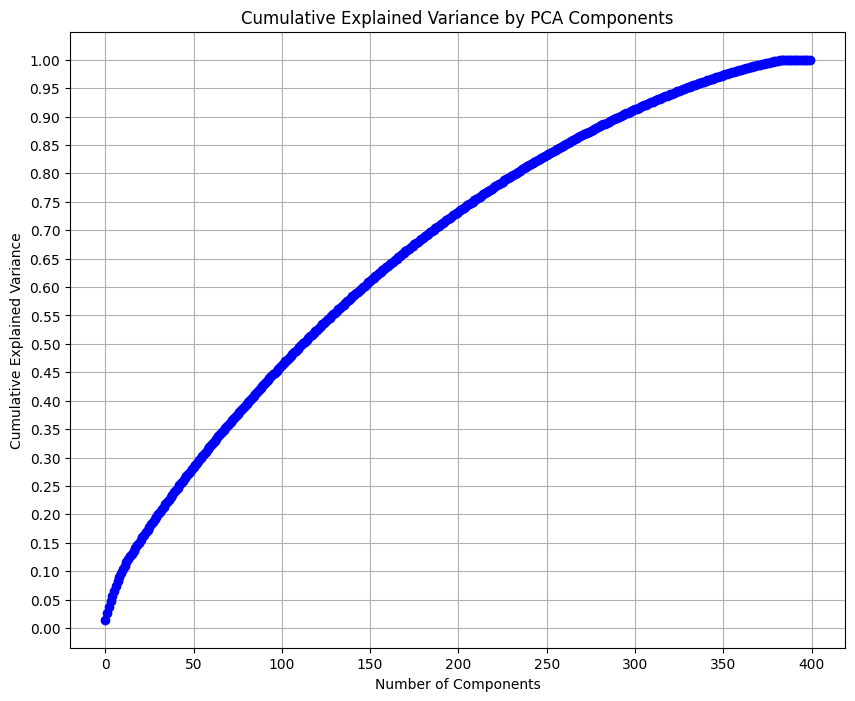

In [ ]:
# Same as before
classification_data = data.drop('Output', axis=1)

training_X = classification_data.drop('Class', axis=1)
training_y = classification_data['Class']

# Now let's try to do PCA decomposition
pca = PCA(svd_solver='auto', random_state=RANDOM_SEED)
pca.fit(training_X)

# Plot cumulative explained variance
cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(10, 8))
plt.plot(cumulative_explained_variance, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components')
plt.grid(True)
plt.yticks(np.arange(0, 1.05, 0.05))
plt.show()

I will proceed with 300 components as they explain more than 90% of the variance and cut the number of predictors by 25%.  
It's also worth noting that the data seems to not behave nicely with PCA, meaning that the components are pretty equal when it comes to explained variance ratio.

In [ ]:
# Now let's try logistic regression with lasso, but on the PCA components as predictors.
classification_data = data.drop('Output', axis=1)

training_X = classification_data.drop('Class', axis=1)
training_y = classification_data['Class']

pca = PCA(n_components=300, svd_solver='auto', random_state=RANDOM_SEED)
pca.fit(training_X)
training_X = pd.DataFrame(pca.transform(training_X))

# Perform the regularization parameter selection as before
regularization_parameters = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]

parameter_f_score = {}
for regularization_parameter in regularization_parameters:
  cross_validation = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)
  f_scores = []

  for (training_indexes, test_indexes) in cross_validation.split(X=training_X, y=training_y):
    fold_training_X = training_X.iloc[training_indexes]
    fold_training_y = training_y.iloc[training_indexes]

    lasso_regression = LogisticRegression(fit_intercept=True, penalty='l1', solver='liblinear', C=regularization_parameter, random_state=RANDOM_SEED)
    lasso_regression.fit(X=fold_training_X, y=fold_training_y)

    fold_test_X = training_X.iloc[test_indexes]
    fold_test_y = training_y.iloc[test_indexes]

    fold_y_prediction = lasso_regression.predict(X=fold_test_X)

    f_scores.append(f1_score(y_true=fold_test_y, y_pred=fold_y_prediction))

  parameter_f_score[regularization_parameter] = (np.mean(f_scores), np.std(f_scores))

print('-- F-Scores for Different Regularization Parameters --')
for regularization_parameter in regularization_parameters:
  print(f'C= {regularization_parameter}: mean= {parameter_f_score[regularization_parameter][0]:.2f}, std= {parameter_f_score[regularization_parameter][1]:.2f}')

-- F-Scores for Different Regularization Parameters --
C= 0.001: mean= 0.00, std= 0.00
C= 0.005: mean= 0.52, std= 0.03
C= 0.01: mean= 0.56, std= 0.03
C= 0.05: mean= 0.54, std= 0.03
C= 0.1: mean= 0.54, std= 0.03
C= 0.5: mean= 0.55, std= 0.04
C= 1: mean= 0.54, std= 0.05
C= 5: mean= 0.54, std= 0.04
C= 10: mean= 0.54, std= 0.04


The regularized models fitted to the PCA components seem to perform pretty much identically to the ones fitted to original predictors.  
Overall, we got basically the same performance with lasso and the base model, however with a massive difference in interpretabilty, because the best lasso model (no PCA, *C*=0.01) uses just 3 predictors, compared to 400 in the base model. Lasso provided us a gain in interpretability.


## Random Forest

In [ ]:
# No special preprocessing as tree methods shouldn't fall victim to the "curse of dimensionality"
classification_data = data.drop('Output', axis=1)

training_X = classification_data.drop('Class', axis=1)
training_y = classification_data['Class']

# Use cross-validation to compare models with different number of estimators
estimators_numbers = [50, 100, 150, 200]

parameter_f_score = {}
for estimators_number in estimators_numbers:
  cross_validation = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)
  f_scores = []

  for (training_indexes, test_indexes) in cross_validation.split(X=training_X, y=training_y):
    fold_training_X = training_X.iloc[training_indexes]
    fold_training_y = training_y.iloc[training_indexes]

    random_forest = RandomForestClassifier(
        n_estimators=estimators_number,
        criterion='gini',
        bootstrap=True,
        n_jobs=-1,
        max_features='sqrt',
        max_depth=10,
        random_state=RANDOM_SEED
    )
    random_forest.fit(X=fold_training_X, y=fold_training_y)

    fold_test_X = training_X.iloc[test_indexes]
    fold_test_y = training_y.iloc[test_indexes]

    fold_y_prediction = random_forest.predict(X=fold_test_X)

    f_scores.append(f1_score(y_true=fold_test_y, y_pred=fold_y_prediction))

  parameter_f_score[estimators_number] = (np.mean(f_scores), np.std(f_scores))

print('-- F-Scores for Different Number of Estimators --')
for estimators_number in estimators_numbers:
  print(f'n_estimators= {estimators_number}: mean= {parameter_f_score[estimators_number][0]:.2f}, std= {parameter_f_score[estimators_number][1]:.2f}')

-- F-Scores for Different Number of Estimators --
n_estimators= 50: mean= 0.68, std= 0.04
n_estimators= 100: mean= 0.69, std= 0.02
n_estimators= 150: mean= 0.70, std= 0.03
n_estimators= 200: mean= 0.71, std= 0.03


Random Forest classifier seems to be performing significantly better than both lasso and the base model. The optimal number of estimators seems to be 200 (out of the tested numbers).  
The parameters *max_features* and *max_depth* were set in order to reduce computation time. The choice of those specific options was purely arbitrary, however it would be too computationally intensive to test even a reasonable amount of combinations.  
This is currently the best model with f-score **31% greater** than the base model. Let's investigate it's feature importance.

In [ ]:
classification_data = data.drop('Output', axis=1)

training_X = classification_data.drop('Class', axis=1)
training_y = classification_data['Class']

random_forest = RandomForestClassifier(
    n_estimators=200,
    criterion='gini',
    bootstrap=True,
    n_jobs=-1,
    max_features='sqrt',
    max_depth=10,
    random_state=RANDOM_SEED)
random_forest.fit(X=training_X, y=training_y)

feature_importances = pd.DataFrame(random_forest.feature_importances_, index=training_X.columns, columns=['Importance']).sort_values(by='Importance', ascending=False)
feature_importances.iloc[list(range(15))]

,Importance
Input240,0.034307
Input330,0.018875
Input41,0.014609
Input293,0.014035
Input2,0.013152
Input256,0.012580
Input396,0.012098
Input40,0.011572
Input238,0.010839
Input38,0.010690


We can see that again, as in the lasso model, inputs 41, 293 and 396 are present in the top10 most important features. However, the most important one is 240 and by a large margin.  
I displayed the top15 predictors in order to show that that only 11 out of the 400 have an importance greater or equal to 0.01. Let's trust the Random Forest model and treat those predictors as if they were in fact more important.  
What would happen if we trained the model just on those predictors?

In [ ]:
classification_data = data.drop('Output', axis=1)

training_X = classification_data.drop('Class', axis=1)
training_y = classification_data['Class']

# Reduce the data to just those top11 predictors
significant_predictors = ['Input240', 'Input330', 'Input41', 'Input293', 'Input2', 'Input256', 'Input396', 'Input40', 'Input238', 'Input38', 'Input246']
training_X = classification_data[significant_predictors]

f_scores = []
cross_validation = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)
for (training_indexes, test_indexes) in cross_validation.split(X=training_X, y=training_y):
  fold_training_X = training_X.iloc[training_indexes]
  fold_training_y = training_y.iloc[training_indexes]

  random_forest = RandomForestClassifier(
      n_estimators=200,
      criterion='gini',
      bootstrap=True,
      n_jobs=-1,
      max_features='sqrt',
      max_depth=10,
      random_state=RANDOM_SEED
  )

  random_forest.fit(X=fold_training_X, y=fold_training_y)
  fold_test_X = training_X.iloc[test_indexes]
  fold_test_y = training_y.iloc[test_indexes]

  fold_y_prediction = random_forest.predict(X=fold_test_X)
  f_scores.append(f1_score(y_true=fold_test_y, y_pred=fold_y_prediction))

print('-- F-Score --')
print(f'mean= {np.mean(f_scores):.2f}, std= {np.std(f_scores):.2f}')

-- F-Score --
mean= 0.81, std= 0.02


Turns out that the model fitted to the subset of important predictors performed significantly better than one fitted to all predictors. The estimated test f-score for this model is **50% higher** than for the base model.  
From now on let's try fitting models first to all predictors and then to this special subset.

## SVM

In [ ]:
# First let's try no preprocessing
classification_data = data.drop('Output', axis=1)

training_X = classification_data.drop('Class', axis=1)
training_y = classification_data['Class']

# Use cross-validation to compare models with different (C, gamma) parameters
C_values = [0.001, 0.01, 0.1, 1, 10]
gamma_values = [0.001, 0.01, 0.1, 1, 10]

parameter_f_score = {}
for C in C_values:
  for gamma in gamma_values:
    cross_validation = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)
    f_scores = []

    for (training_indexes, test_indexes) in cross_validation.split(X=training_X, y=training_y):
      fold_training_X = training_X.iloc[training_indexes]
      fold_training_y = training_y.iloc[training_indexes]

      svm = SVC(kernel='rbf', C=C, gamma=gamma, random_state=RANDOM_SEED)
      svm.fit(X=fold_training_X, y=fold_training_y)

      fold_test_X = training_X.iloc[test_indexes]
      fold_test_y = training_y.iloc[test_indexes]

      fold_y_prediction = svm.predict(X=fold_test_X)

      f_scores.append(f1_score(y_true=fold_test_y, y_pred=fold_y_prediction))

    parameter_f_score[(C, gamma)] = (np.mean(f_scores), np.std(f_scores))

print('-- F-Scores for Different Parameters --')
for (C, gamma) in parameter_f_score:
  print(f'C= {C}, gamma= {gamma}: mean= {parameter_f_score[(C, gamma)][0]:.2f}, std= {parameter_f_score[(C, gamma)][1]:.2f}')

-- F-Scores for Different Parameters --
C= 0.001, gamma= 0.001: mean= 0.67, std= 0.00
C= 0.001, gamma= 0.01: mean= 0.67, std= 0.00
C= 0.001, gamma= 0.1: mean= 0.67, std= 0.00
C= 0.001, gamma= 1: mean= 0.67, std= 0.00
C= 0.001, gamma= 10: mean= 0.67, std= 0.00
C= 0.01, gamma= 0.001: mean= 0.67, std= 0.00
C= 0.01, gamma= 0.01: mean= 0.67, std= 0.00
C= 0.01, gamma= 0.1: mean= 0.67, std= 0.00
C= 0.01, gamma= 1: mean= 0.67, std= 0.00
C= 0.01, gamma= 10: mean= 0.67, std= 0.00
C= 0.1, gamma= 0.001: mean= 0.67, std= 0.00
C= 0.1, gamma= 0.01: mean= 0.67, std= 0.00
C= 0.1, gamma= 0.1: mean= 0.67, std= 0.00
C= 0.1, gamma= 1: mean= 0.67, std= 0.00
C= 0.1, gamma= 10: mean= 0.67, std= 0.00
C= 1, gamma= 0.001: mean= 0.56, std= 0.02
C= 1, gamma= 0.01: mean= 0.68, std= 0.01
C= 1, gamma= 0.1: mean= 0.67, std= 0.00
C= 1, gamma= 1: mean= 0.67, std= 0.00
C= 1, gamma= 10: mean= 0.67, std= 0.00
C= 10, gamma= 0.001: mean= 0.55, std= 0.03
C= 10, gamma= 0.01: mean= 0.67, std= 0.01
C= 10, gamma= 0.1: mean= 0.67,

SVM with Gaussian kernel performs significantly better than the base model - **26% higher** f-score for *C*=1, *gamma*=0.01.  
Yet still a little bit worse than Random Forest, which remains the top model. Let's check if PCA changes anything.

In [ ]:
# Let's try PCA decomposition with 300 components
# The choice of 300 was explained previously
classification_data = data.drop('Output', axis=1)

training_X = classification_data.drop('Class', axis=1)
training_y = classification_data['Class']

pca = PCA(n_components=300, svd_solver='auto', random_state=RANDOM_SEED)
pca.fit(training_X)
training_X = pd.DataFrame(pca.transform(training_X))

# Use cross-validation to compare models with different (C, gamma) parameters
C_values = [0.001, 0.01, 0.1, 1, 10]
gamma_values = [0.001, 0.01, 0.1, 1, 10]

parameter_f_score = {}
for C in C_values:
  for gamma in gamma_values:
    cross_validation = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)
    f_scores = []

    for (training_indexes, test_indexes) in cross_validation.split(X=training_X, y=training_y):
      fold_training_X = training_X.iloc[training_indexes]
      fold_training_y = training_y.iloc[training_indexes]

      svm = SVC(kernel='rbf', C=C, gamma=gamma, random_state=RANDOM_SEED)
      svm.fit(X=fold_training_X, y=fold_training_y)

      fold_test_X = training_X.iloc[test_indexes]
      fold_test_y = training_y.iloc[test_indexes]

      fold_y_prediction = svm.predict(X=fold_test_X)

      f_scores.append(f1_score(y_true=fold_test_y, y_pred=fold_y_prediction))

    parameter_f_score[(C, gamma)] = (np.mean(f_scores), np.std(f_scores))

print('-- F-Scores for Different Parameters --')
for (C, gamma) in parameter_f_score:
  print(f'C= {C}, gamma= {gamma}: mean= {parameter_f_score[(C, gamma)][0]:.2f}, std= {parameter_f_score[(C, gamma)][1]:.2f}')

-- F-Scores for Different Parameters --
C= 0.001, gamma= 0.001: mean= 0.67, std= 0.00
C= 0.001, gamma= 0.01: mean= 0.67, std= 0.00
C= 0.001, gamma= 0.1: mean= 0.67, std= 0.00
C= 0.001, gamma= 1: mean= 0.67, std= 0.00
C= 0.001, gamma= 10: mean= 0.67, std= 0.00
C= 0.01, gamma= 0.001: mean= 0.67, std= 0.00
C= 0.01, gamma= 0.01: mean= 0.67, std= 0.00
C= 0.01, gamma= 0.1: mean= 0.67, std= 0.00
C= 0.01, gamma= 1: mean= 0.67, std= 0.00
C= 0.01, gamma= 10: mean= 0.67, std= 0.00
C= 0.1, gamma= 0.001: mean= 0.67, std= 0.00
C= 0.1, gamma= 0.01: mean= 0.67, std= 0.00
C= 0.1, gamma= 0.1: mean= 0.67, std= 0.00
C= 0.1, gamma= 1: mean= 0.67, std= 0.00
C= 0.1, gamma= 10: mean= 0.67, std= 0.00
C= 1, gamma= 0.001: mean= 0.56, std= 0.03
C= 1, gamma= 0.01: mean= 0.67, std= 0.02
C= 1, gamma= 0.1: mean= 0.67, std= 0.00
C= 1, gamma= 1: mean= 0.67, std= 0.00
C= 1, gamma= 10: mean= 0.67, std= 0.00
C= 10, gamma= 0.001: mean= 0.57, std= 0.04
C= 10, gamma= 0.01: mean= 0.65, std= 0.03
C= 10, gamma= 0.1: mean= 0.67,

Similarly to logistic regression with lasso, SVM performed nearly identically with and without PCA decomposition.  
Let's see how the SVM performs with just the special predictors.

In [ ]:
classification_data = data.drop('Output', axis=1)

training_X = classification_data.drop('Class', axis=1)
training_y = classification_data['Class']

significant_predictors = ['Input240', 'Input330', 'Input41', 'Input293', 'Input2', 'Input256', 'Input396', 'Input40', 'Input238', 'Input38', 'Input246']
training_X = classification_data[significant_predictors]

# Use cross-validation to compare models with different (C, gamma) parameters
C_values = [0.001, 0.01, 0.1, 1, 10]
gamma_values = [0.001, 0.01, 0.1, 1, 10]

parameter_f_score = {}
for C in C_values:
  for gamma in gamma_values:
    cross_validation = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)
    f_scores = []

    for (training_indexes, test_indexes) in cross_validation.split(X=training_X, y=training_y):
      fold_training_X = training_X.iloc[training_indexes]
      fold_training_y = training_y.iloc[training_indexes]

      svm = SVC(kernel='rbf', C=C, gamma=gamma, random_state=RANDOM_SEED)
      svm.fit(X=fold_training_X, y=fold_training_y)

      fold_test_X = training_X.iloc[test_indexes]
      fold_test_y = training_y.iloc[test_indexes]

      fold_y_prediction = svm.predict(X=fold_test_X)

      f_scores.append(f1_score(y_true=fold_test_y, y_pred=fold_y_prediction))

    parameter_f_score[(C, gamma)] = (np.mean(f_scores), np.std(f_scores))

print('-- F-Scores for Different Parameters --')
for (C, gamma) in parameter_f_score:
  print(f'C= {C}, gamma= {gamma}: mean= {parameter_f_score[(C, gamma)][0]:.2f}, std= {parameter_f_score[(C, gamma)][1]:.2f}')

-- F-Scores for Different Parameters --
C= 0.001, gamma= 0.001: mean= 0.67, std= 0.00
C= 0.001, gamma= 0.01: mean= 0.67, std= 0.00
C= 0.001, gamma= 0.1: mean= 0.67, std= 0.00
C= 0.001, gamma= 1: mean= 0.67, std= 0.00
C= 0.001, gamma= 10: mean= 0.67, std= 0.00
C= 0.01, gamma= 0.001: mean= 0.67, std= 0.00
C= 0.01, gamma= 0.01: mean= 0.67, std= 0.00
C= 0.01, gamma= 0.1: mean= 0.70, std= 0.01
C= 0.01, gamma= 1: mean= 0.67, std= 0.00
C= 0.01, gamma= 10: mean= 0.67, std= 0.00
C= 0.1, gamma= 0.001: mean= 0.67, std= 0.00
C= 0.1, gamma= 0.01: mean= 0.61, std= 0.02
C= 0.1, gamma= 0.1: mean= 0.74, std= 0.03
C= 0.1, gamma= 1: mean= 0.81, std= 0.02
C= 0.1, gamma= 10: mean= 0.67, std= 0.00
C= 1, gamma= 0.001: mean= 0.58, std= 0.03
C= 1, gamma= 0.01: mean= 0.68, std= 0.03
C= 1, gamma= 0.1: mean= 0.78, std= 0.02
C= 1, gamma= 1: mean= 0.84, std= 0.02
C= 1, gamma= 10: mean= 0.73, std= 0.02
C= 10, gamma= 0.001: mean= 0.60, std= 0.03
C= 10, gamma= 0.01: mean= 0.73, std= 0.03
C= 10, gamma= 0.1: mean= 0.81,

Based on the performed cross-validation the optimal parameters seem to be *C*=1, *gamma*=1. Fitting the SVM to the special subset is estimated to be better than the model fitted to all predictors as well as the previous best model - Random Forest.  
The best SVM achieves an f-score **56% better** than the base model.

## Boosting

In [ ]:
# No special preprocessing as tree methods shouldn't fall victim to the "curse of dimensionality"
classification_data = data.drop('Output', axis=1)

training_X = classification_data.drop('Class', axis=1)
training_y = classification_data['Class']

learning_rates = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1]
cross_validation = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)

parameter_f_score = {}
for learning_rate in learning_rates:
  f_scores = []
  for (training_indexes, test_indexes) in cross_validation.split(X=training_X, y=training_y):
    fold_training_X = training_X.iloc[training_indexes]
    fold_training_y = training_y.iloc[training_indexes]

    ada_boost = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(
            criterion='gini',
            max_depth=1,
            random_state=RANDOM_SEED
        ),
        learning_rate=learning_rate,
        n_estimators=10,
        random_state=RANDOM_SEED
    )

    ada_boost.fit(X=fold_training_X, y=fold_training_y)

    fold_test_X = training_X.iloc[test_indexes]
    fold_test_y = training_y.iloc[test_indexes]

    fold_y_prediction = ada_boost.predict(X=fold_test_X)

    f_scores.append(f1_score(y_true=fold_test_y, y_pred=fold_y_prediction))

  parameter_f_score[learning_rate] = (np.mean(f_scores), np.std(f_scores))

print('-- F-Scores for Different Learning Rates --')
for learning_rate in learning_rates:
  print(f'learning_rate= {learning_rate}: mean= {parameter_f_score[learning_rate][0]:.2f}, std= {parameter_f_score[learning_rate][1]:.2f}')

-- F-Scores for Different Learning Rates --
learning_rate= 0.001: mean= 0.69, std= 0.03
learning_rate= 0.005: mean= 0.69, std= 0.03
learning_rate= 0.01: mean= 0.69, std= 0.03
learning_rate= 0.05: mean= 0.69, std= 0.02
learning_rate= 0.1: mean= 0.69, std= 0.02
learning_rate= 0.5: mean= 0.66, std= 0.03
learning_rate= 1: mean= 0.62, std= 0.05


AdaBoost performs worse than both Random Forest and SVM, but still sigificantly better than the base model with **28% higher** f-score.  
Let's try to improve the model with *learning_rate*=0.1 by increasing it's trees' depth.

In [ ]:
# As before
classification_data = data.drop('Output', axis=1)

training_X = classification_data.drop('Class', axis=1)
training_y = classification_data['Class']

cross_validation = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)

f_scores = []
for (training_indexes, test_indexes) in cross_validation.split(X=training_X, y=training_y):
  fold_training_X = training_X.iloc[training_indexes]
  fold_training_y = training_y.iloc[training_indexes]

  ada_boost = AdaBoostClassifier(
      estimator=DecisionTreeClassifier(
          criterion='gini',
          max_depth=10,
          random_state=RANDOM_SEED
      ),
      learning_rate=0.1,
      n_estimators=10,
      random_state=RANDOM_SEED
  )

  ada_boost.fit(X=fold_training_X, y=fold_training_y)

  fold_test_X = training_X.iloc[test_indexes]
  fold_test_y = training_y.iloc[test_indexes]

  fold_y_prediction = ada_boost.predict(X=fold_test_X)

  f_scores.append(f1_score(y_true=fold_test_y, y_pred=fold_y_prediction))

print('-- F-Score --')
print(f'mean= {np.mean(f_scores):.2f}, std= {np.std(f_scores):.2f}')

-- F-Score --
mean= 0.69, std= 0.03


The increased depth doesn't seem to make a difference. Let's look at feature importances.

In [ ]:
classification_data = data.drop('Output', axis=1)

training_X = classification_data.drop('Class', axis=1)
training_y = classification_data['Class']

ada_boost = AdaBoostClassifier(
      estimator=DecisionTreeClassifier(
          criterion='gini',
          max_depth=10,
          random_state=RANDOM_SEED
      ),
      learning_rate=0.1,
      n_estimators=10,
      random_state=RANDOM_SEED
)

ada_boost.fit(X=training_X, y=training_y)

feature_importances = pd.DataFrame(ada_boost.feature_importances_, index=training_X.columns, columns=['Importance']).sort_values(by='Importance', ascending=False)
feature_importances.iloc[list(range(10))]

,Importance
Input240,0.100481
Input41,0.071029
Input330,0.057298
Input256,0.054469
Input40,0.029205
Input110,0.026366
Input95,0.021794
Input38,0.021092
Input2,0.018756
Input396,0.014105


The hierarchy looks similar to Random Forest's, however the differences in importances are much smaller. Pretty much all the top predictors from Random Forest are also present here, with 240 being the most influential.  
Let's try boosting again, but now on the special subset of predictors.

In [ ]:
classification_data = data.drop('Output', axis=1)

training_X = classification_data.drop('Class', axis=1)
training_y = classification_data['Class']

significant_predictors = ['Input240', 'Input330', 'Input41', 'Input293', 'Input2', 'Input256', 'Input396', 'Input40', 'Input238', 'Input38', 'Input246']
training_X = classification_data[significant_predictors]

learning_rates = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1]
cross_validation = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)

parameter_f_score = {}
for learning_rate in learning_rates:
  f_scores = []
  for (training_indexes, test_indexes) in cross_validation.split(X=training_X, y=training_y):
    fold_training_X = training_X.iloc[training_indexes]
    fold_training_y = training_y.iloc[training_indexes]

    ada_boost = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(
            criterion='gini',
            max_depth=1,
            random_state=RANDOM_SEED
        ),
        learning_rate=learning_rate,
        n_estimators=100,
        random_state=RANDOM_SEED
    )

    ada_boost.fit(X=fold_training_X, y=fold_training_y)

    fold_test_X = training_X.iloc[test_indexes]
    fold_test_y = training_y.iloc[test_indexes]

    fold_y_prediction = ada_boost.predict(X=fold_test_X)

    f_scores.append(f1_score(y_true=fold_test_y, y_pred=fold_y_prediction))

  parameter_f_score[learning_rate] = (np.mean(f_scores), np.std(f_scores))

print('-- F-Scores for Different Learning Rates --')
for learning_rate in learning_rates:
  print(f'learning_rate= {learning_rate}: mean= {parameter_f_score[learning_rate][0]:.2f}, std= {parameter_f_score[learning_rate][1]:.2f}')

-- F-Scores for Different Learning Rates --
learning_rate= 0.001: mean= 0.69, std= 0.03
learning_rate= 0.005: mean= 0.69, std= 0.02
learning_rate= 0.01: mean= 0.69, std= 0.02
learning_rate= 0.05: mean= 0.68, std= 0.03
learning_rate= 0.1: mean= 0.68, std= 0.02
learning_rate= 0.5: mean= 0.67, std= 0.02
learning_rate= 1: mean= 0.68, std= 0.02


The results seem to be just marginally better than the previous boosting models.  
I am aware that the comparison is unfair, because the number of estimators in the models fitted to the subset is much greater, however it's because of the computing time. Less predictors allow for greater amount of estimators with the same training time.  
Let's explore *learning_rate*=0.01 (optimal value based on the cross-validation), but with bigger *max_depth* parameter.

In [ ]:
classification_data = data.drop('Output', axis=1)

training_X = classification_data.drop('Class', axis=1)
training_y = classification_data['Class']

significant_predictors = ['Input240', 'Input330', 'Input41', 'Input293', 'Input2', 'Input256', 'Input396', 'Input40', 'Input238', 'Input38', 'Input246']
training_X = classification_data[significant_predictors]

cross_validation = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)

f_scores = []
for (training_indexes, test_indexes) in cross_validation.split(X=training_X, y=training_y):
  fold_training_X = training_X.iloc[training_indexes]
  fold_training_y = training_y.iloc[training_indexes]

  ada_boost = AdaBoostClassifier(
      estimator=DecisionTreeClassifier(
          criterion='gini',
          max_depth=10,
          random_state=RANDOM_SEED
      ),
      learning_rate=0.01,
      n_estimators=100,
      random_state=RANDOM_SEED
  )

  ada_boost.fit(X=fold_training_X, y=fold_training_y)

  fold_test_X = training_X.iloc[test_indexes]
  fold_test_y = training_y.iloc[test_indexes]

  fold_y_prediction = ada_boost.predict(X=fold_test_X)

  f_scores.append(f1_score(y_true=fold_test_y, y_pred=fold_y_prediction))

print('-- F-Score --')
print(f'mean= {np.mean(f_scores):.2f}, std= {np.std(f_scores):.2f}')

-- F-Score --
mean= 0.77, std= 0.03


*max_depth* seems to have made a difference this time. This model (*learning_rate*=0.01, *n_estimators*=100, *max_depth*=10) is estimated to have the highest test f-score out of the boosting models, achieving a score **43% higher** than the base model.  
Nonetheless SVM still remains the best classifier.

## Final Choice of the Classifier

The cell below will compare my best classifier with the baseline (if "validation_data.csv" is present).

In [ ]:
# SVM (C=1, gamma=1) fitted to the special subset had the highest estimated test f-score, so it will be used as the classifier of choice
training_data = data.drop('Output', axis=1)

training_X = training_data.drop('Class', axis=1)
training_y = training_data['Class']

baseline_model = LogisticRegression(fit_intercept=True, penalty=None, solver='lbfgs', random_state=RANDOM_SEED)
baseline_model.fit(X=training_X, y=training_y)

validation_data = pd.read_csv('validation_data.csv', sep=';')
validation_data = validation_data.drop('Output', axis=1)

validation_X = validation_data.drop('Class', axis=1)
validation_y = validation_data['Class']

baseline_y_prediction = baseline_model.predict(X=validation_X)

baseline_precision = precision_score(y_true=validation_y, y_pred=baseline_y_prediction)
baseline_recall = recall_score(y_true=validation_y, y_pred=baseline_y_prediction)

print('-- Baseline Model Metrics')
print(f'Precision: {baseline_precision:.2f}')
print(f'Recall: {baseline_recall:.2f}\n')

significant_predictors = ['Input240', 'Input330', 'Input41', 'Input293', 'Input2', 'Input256', 'Input396', 'Input40', 'Input238', 'Input38', 'Input246']
training_X = training_data[significant_predictors]

classifier = SVC(kernel='rbf', C=1, gamma=1, random_state=RANDOM_SEED)
classifier.fit(X=training_X, y=training_y)

validation_X = validation_data[significant_predictors]
classifier_y_prediction = classifier.predict(X=validation_X)

classifier_precision = precision_score(y_true=validation_y, y_pred=classifier_y_prediction)
classifier_recall = recall_score(y_true=validation_y, y_pred=classifier_y_prediction)

print('-- Best Classifier Metrics --')
print(f'Precision: {classifier_precision:.2f}')
print(f'Recall: {classifier_recall:.2f}\n')

print('-- Overall -- ')
print(f'Precision ratio: {classifier_precision / baseline_precision:.2f}')
print(f'Recall ratio: {classifier_recall / baseline_recall:.2f}')

# More Advanced Regression

## Linear Regression with Lasso

In [ ]:
regression_data = data.drop('Class', axis=1)

training_X = regression_data.drop('Output', axis=1)
training_y = regression_data['Output']

def rmse(model, X, y):
  return np.sqrt(np.mean((model.predict(X=X) - y)**2))

regularization_parameters = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]
cross_validation = KFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)

parameter_rmse = {}
parameter_r2 = {}
for regularization_parameter in regularization_parameters:
  cross_validation_rmse = []
  cross_validation_r2 = []
  for (training_indexes, test_indexes) in cross_validation.split(X=training_X, y=training_y):
    fold_training_X = training_X.iloc[training_indexes]
    fold_training_y = training_y.iloc[training_indexes]
    lasso_regression = Lasso(alpha=regularization_parameter, fit_intercept=True, random_state=RANDOM_SEED)
    lasso_regression.fit(X=fold_training_X, y=fold_training_y)

    fold_test_X = training_X.iloc[test_indexes]
    fold_test_y = training_y.iloc[test_indexes]

    cross_validation_rmse.append(rmse(model=lasso_regression, X=fold_test_X, y=fold_test_y))
    cross_validation_r2.append(lasso_regression.score(X=fold_test_X, y=fold_test_y))

  parameter_rmse[regularization_parameter] = (np.mean(cross_validation_rmse), np.std(cross_validation_rmse))
  parameter_r2[regularization_parameter] = (np.mean(cross_validation_r2), np.std(cross_validation_r2))

print('-- RMSE for Different Regularization Parameters --')
for regularization_parameter in regularization_parameters:
  print(f'alpha= {regularization_parameter}: mean= {parameter_rmse[regularization_parameter][0]:.2f}, std= {parameter_rmse[regularization_parameter][1]:.2f}')

print('\n-- R^2 for Different Regularization Parameters --')
for regularization_parameter in regularization_parameters:
  print(f'alpha= {regularization_parameter}: mean= {parameter_r2[regularization_parameter][0]:.2f}, std= {parameter_r2[regularization_parameter][1]:.2f}')

-- RMSE for Different Regularization Parameters --
alpha= 0.001: mean= 2.77, std= 0.15
alpha= 0.005: mean= 2.73, std= 0.14
alpha= 0.01: mean= 2.69, std= 0.14
alpha= 0.05: mean= 2.55, std= 0.12
alpha= 0.1: mean= 2.54, std= 0.11
alpha= 0.5: mean= 3.00, std= 0.15
alpha= 1: mean= 3.51, std= 0.20
alpha= 5: mean= 3.56, std= 0.19
alpha= 10: mean= 3.56, std= 0.19

-- R^2 for Different Regularization Parameters --
alpha= 0.001: mean= 0.38, std= 0.11
alpha= 0.005: mean= 0.40, std= 0.10
alpha= 0.01: mean= 0.42, std= 0.10
alpha= 0.05: mean= 0.48, std= 0.07
alpha= 0.1: mean= 0.48, std= 0.06
alpha= 0.5: mean= 0.28, std= 0.03
alpha= 1: mean= 0.02, std= 0.01
alpha= 5: mean= -0.01, std= 0.01
alpha= 10: mean= -0.01, std= 0.01


The RMSE seems to be pretty high overall and the R^2 quite low. What is also worrying is the relatively high standard deviation in model performance which suggests instability.  
Still, the Lasso has a **26% higher R^2**, **9% lower RMSE** and significanly lower standard deviation in performance than the base model.  
Let's see which predictors did the Lasso select in the best model (*alpha*=0.1).

In [ ]:
regression_data = data.drop('Class', axis=1)

training_X = regression_data.drop('Output', axis=1)
training_y = regression_data['Output']

lasso_regression = Lasso(alpha=0.1, fit_intercept=True, random_state=RANDOM_SEED)
lasso_regression.fit(X=training_X, y=training_y)

nonzero_predictors = []
predictor_coefficient = {}
for (predictor, coefficient) in enumerate(lasso_regression.coef_):
  if coefficient != 0:
    nonzero_predictors.append(predictor + 1)
    predictor_coefficient[predictor + 1] = coefficient

nonzero_predictors = ['Input' + str(predictor) for predictor in nonzero_predictors]
print(f'{len(nonzero_predictors)} predictors with nonzero coefficients')

list(sorted([(round(float(predictor_coefficient[predictor]), ndigits=4), f'Input{predictor}') for predictor in predictor_coefficient], reverse=True))

48 predictors with nonzero coefficients


[(0.8548, 'Index223'),
 (0.8528, 'Index83'),
 (0.7444, 'Index167'),
 (0.6639, 'Index193'),
 (0.6439, 'Index292'),
 (0.6207, 'Index342'),
 (0.5755, 'Index184'),
 (0.4854, 'Index136'),
 (0.4561, 'Index173'),
 (0.3658, 'Index387'),
 (0.36, 'Index18'),
 (0.277, 'Index241'),
 (0.2625, 'Index59'),
 (0.2472, 'Index389'),
 (0.0395, 'Index250'),
 (0.0267, 'Index286'),
 (0.0241, 'Index226'),
 (0.0204, 'Index236'),
 (0.0148, 'Index363'),
 (0.0133, 'Index94'),
 (0.0132, 'Index41'),
 (0.0105, 'Index194'),
 (0.0098, 'Index156'),
 (0.0095, 'Index132'),
 (0.0088, 'Index304'),
 (0.007, 'Index20'),
 (0.0066, 'Index65'),
 (0.0054, 'Index160'),
 (0.0051, 'Index393'),
 (0.0044, 'Index254'),
 (0.0035, 'Index295'),
 (0.0033, 'Index179'),
 (0.0026, 'Index44'),
 (0.0001, 'Index335'),
 (-0.0025, 'Index285'),
 (-0.006, 'Index48'),
 (-0.0068, 'Index235'),
 (-0.0089, 'Index191'),
 (-0.0093, 'Index112'),
 (-0.0108, 'Index232'),
 (-0.0143, 'Index345'),
 (-0.0162, 'Index172'),
 (-0.0169, 'Index298'),
 (-0.0187, 'Inde

The coefficients in the model suggest that there exists a subset of 14 predictors that are far more important for predicting the 'Output' than the rest.  
This subset consists of predictors:  
223, 83, 167, 193, 292, 342, 184, 136, 173, 387, 18, 241, 59, 389  
All of them have a coefficient greater than 0.25 (significantly larger than the rest even when accounting for sign).  
What's interesting is that this subset and the special subset from the classification section have no overlap.  
Let's see what happens if we fit a model to just those special predictors.

In [ ]:
regression_data = data.drop('Class', axis=1)

training_X = regression_data.drop('Output', axis=1)
training_y = regression_data['Output']

significant_predictors = ['Input223', 'Input83', 'Input167', 'Input193', 'Input292', 'Input342', 'Input184', 'Input136', 'Input173', 'Input387', 'Input18', 'Input241', 'Input59', 'Input389']
training_X = regression_data[significant_predictors]

def rmse(model, X, y):
  return np.sqrt(np.mean((model.predict(X=X) - y)**2))

regularization_parameters = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]
cross_validation = KFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)

parameter_rmse = {}
parameter_r2 = {}
for regularization_parameter in regularization_parameters:
  cross_validation_rmse = []
  cross_validation_r2 = []
  for (training_indexes, test_indexes) in cross_validation.split(X=training_X, y=training_y):
    fold_training_X = training_X.iloc[training_indexes]
    fold_training_y = training_y.iloc[training_indexes]
    lasso_regression = Lasso(alpha=regularization_parameter, fit_intercept=True, random_state=RANDOM_SEED)
    lasso_regression.fit(X=fold_training_X, y=fold_training_y)

    fold_test_X = training_X.iloc[test_indexes]
    fold_test_y = training_y.iloc[test_indexes]

    cross_validation_rmse.append(rmse(model=lasso_regression, X=fold_test_X, y=fold_test_y))
    cross_validation_r2.append(lasso_regression.score(X=fold_test_X, y=fold_test_y))

  parameter_rmse[regularization_parameter] = (np.mean(cross_validation_rmse), np.std(cross_validation_rmse))
  parameter_r2[regularization_parameter] = (np.mean(cross_validation_r2), np.std(cross_validation_r2))

print('-- RMSE for Different Regularization Parameters --')
for regularization_parameter in regularization_parameters:
  print(f'alpha= {regularization_parameter}: mean= {parameter_rmse[regularization_parameter][0]:.2f}, std= {parameter_rmse[regularization_parameter][1]:.2f}')

print('\n-- R^2 for Different Regularization Parameters --')
for regularization_parameter in regularization_parameters:
  print(f'alpha= {regularization_parameter}: mean= {parameter_r2[regularization_parameter][0]:.2f}, std= {parameter_r2[regularization_parameter][1]:.2f}')

-- RMSE for Different Regularization Parameters --
alpha= 0.001: mean= 2.48, std= 0.11
alpha= 0.005: mean= 2.48, std= 0.11
alpha= 0.01: mean= 2.48, std= 0.11
alpha= 0.05: mean= 2.49, std= 0.11
alpha= 0.1: mean= 2.52, std= 0.11
alpha= 0.5: mean= 3.00, std= 0.15
alpha= 1: mean= 3.51, std= 0.20
alpha= 5: mean= 3.56, std= 0.19
alpha= 10: mean= 3.56, std= 0.19

-- R^2 for Different Regularization Parameters --
alpha= 0.001: mean= 0.51, std= 0.07
alpha= 0.005: mean= 0.51, std= 0.07
alpha= 0.01: mean= 0.51, std= 0.07
alpha= 0.05: mean= 0.50, std= 0.06
alpha= 0.1: mean= 0.49, std= 0.06
alpha= 0.5: mean= 0.28, std= 0.03
alpha= 1: mean= 0.02, std= 0.01
alpha= 5: mean= -0.01, std= 0.01
alpha= 10: mean= -0.01, std= 0.01


New models fitted to the subset of predictors have improved scores both in R^2 and RMSE. Now the best *alpha* seems to be 0.01.  
Improved Lasso model has **34% better R^2** and **11% lower RMSE** than the base model.  
Let's look at the new coefficients.


In [ ]:
regression_data = data.drop('Class', axis=1)

training_X = regression_data.drop('Output', axis=1)
training_y = regression_data['Output']

significant_predictors = ['Input223', 'Input83', 'Input167', 'Input193', 'Input292', 'Input342', 'Input184', 'Input136', 'Input173', 'Input387', 'Input18', 'Input241', 'Input59', 'Input389']
training_X = regression_data[significant_predictors]

lasso_regression = Lasso(alpha=0.01, fit_intercept=True, random_state=RANDOM_SEED)
lasso_regression.fit(X=training_X, y=training_y)

nonzero_predictors = []
predictor_coefficient = {}
for (predictor, coefficient) in enumerate(lasso_regression.coef_):
  if coefficient != 0:
    nonzero_predictors.append(predictor + 1)
    predictor_coefficient[predictor + 1] = coefficient

nonzero_predictors = ['Input' + str(predictor) for predictor in nonzero_predictors]
print(f'{len(nonzero_predictors)} predictors with nonzero coefficients')

list(sorted([(round(float(predictor_coefficient[predictor]), ndigits=4), significant_predictors[predictor-1]) for predictor in predictor_coefficient], reverse=True))

14 predictors with nonzero coefficients


[(0.9784, 'Input223'),
 (0.9365, 'Input83'),
 (0.87, 'Input167'),
 (0.8108, 'Input342'),
 (0.7497, 'Input292'),
 (0.7258, 'Input193'),
 (0.7254, 'Input184'),
 (0.5334, 'Input387'),
 (0.5313, 'Input173'),
 (0.5131, 'Input136'),
 (0.4633, 'Input18'),
 (0.4378, 'Input59'),
 (0.4081, 'Input241'),
 (0.3236, 'Input389')]

Turns out that the Lasso did not further erase any predictors.  
The order of predictor importance changed only slightly with most of them staying in their respective place (compared to the order we have seen before).

## Random Forest

In [ ]:
regression_data = data.drop('Class', axis=1)

training_X = regression_data.drop('Output', axis=1)
training_y = regression_data['Output']

def rmse(model, X, y):
  return np.sqrt(np.mean((model.predict(X=X) - y)**2))

estimators_numbers = [50, 100, 150, 200]

parameter_rmse = {}
parameter_r2 = {}
for estimators_number in estimators_numbers:
  cross_validation_rmse = []
  cross_validation_r2 = []

  cross_validation = KFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)
  for (training_indexes, test_indexes) in cross_validation.split(X=training_X, y=training_y):
    fold_training_X = training_X.iloc[training_indexes]
    fold_training_y = training_y.iloc[training_indexes]

    random_forest = RandomForestRegressor(
        n_estimators=estimators_number,
        criterion='squared_error',
        max_depth=10,
        max_features='sqrt',
        bootstrap=True,
        n_jobs=-1,
        random_state=RANDOM_SEED
    )

    random_forest.fit(X=fold_training_X, y=fold_training_y)

    fold_test_X = training_X.iloc[test_indexes]
    fold_test_y = training_y.iloc[test_indexes]

    cross_validation_rmse.append(rmse(model=random_forest, X=fold_test_X, y=fold_test_y))
    cross_validation_r2.append(random_forest.score(X=fold_test_X, y=fold_test_y))

  parameter_rmse[estimators_number] = (np.mean(cross_validation_rmse), np.std(cross_validation_rmse))
  parameter_r2[estimators_number] = (np.mean(cross_validation_r2), np.std(cross_validation_r2))

print('-- RMSE for Different Estimators Numbers --')
for estimators_number in estimators_numbers:
  print(f'n_estimators= {estimators_number}: mean= {parameter_rmse[estimators_number][0]:.2f}, std= {parameter_rmse[estimators_number][1]:.2f}')

print('\n-- R^2 for Different Estimators Numbers --')
for estimators_number in estimators_numbers:
  print(f'n_estimators= {estimators_number}: mean= {parameter_r2[estimators_number][0]:.2f}, std= {parameter_r2[estimators_number][1]:.2f}')

-- RMSE for Different Estimators Numbers --
n_estimators= 50: mean= 3.21, std= 0.17
n_estimators= 100: mean= 3.19, std= 0.17
n_estimators= 150: mean= 3.18, std= 0.17
n_estimators= 200: mean= 3.18, std= 0.17

-- R^2 for Different Estimators Numbers --
n_estimators= 50: mean= 0.18, std= 0.02
n_estimators= 100: mean= 0.19, std= 0.02
n_estimators= 150: mean= 0.19, std= 0.02
n_estimators= 200: mean= 0.20, std= 0.02


Looks as if Random Forest is not the best method for regression on this dataset.  
The base model is much better.

In [ ]:
regression_data = data.drop('Class', axis=1)

training_X = regression_data.drop('Output', axis=1)
training_y = regression_data['Output']

significant_predictors = ['Input223', 'Input83', 'Input167', 'Input193', 'Input292', 'Input342', 'Input184', 'Input136', 'Input173', 'Input387', 'Input18', 'Input241', 'Input59', 'Input389']
training_X = regression_data[significant_predictors]

def rmse(model, X, y):
  return np.sqrt(np.mean((model.predict(X=X) - y)**2))

estimators_numbers = [50, 100, 150, 200]

parameter_rmse = {}
parameter_r2 = {}
for estimators_number in estimators_numbers:
  cross_validation_rmse = []
  cross_validation_r2 = []

  cross_validation = KFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)
  for (training_indexes, test_indexes) in cross_validation.split(X=training_X, y=training_y):
    fold_training_X = training_X.iloc[training_indexes]
    fold_training_y = training_y.iloc[training_indexes]

    random_forest = RandomForestRegressor(
        n_estimators=estimators_number,
        criterion='squared_error',
        max_depth=10,
        max_features='sqrt',
        bootstrap=True,
        n_jobs=-1,
        random_state=RANDOM_SEED
    )

    random_forest.fit(X=fold_training_X, y=fold_training_y)

    fold_test_X = training_X.iloc[test_indexes]
    fold_test_y = training_y.iloc[test_indexes]

    cross_validation_rmse.append(rmse(model=random_forest, X=fold_test_X, y=fold_test_y))
    cross_validation_r2.append(random_forest.score(X=fold_test_X, y=fold_test_y))

  parameter_rmse[estimators_number] = (np.mean(cross_validation_rmse), np.std(cross_validation_rmse))
  parameter_r2[estimators_number] = (np.mean(cross_validation_r2), np.std(cross_validation_r2))

print('-- RMSE for Different Estimators Numbers --')
for estimators_number in estimators_numbers:
  print(f'n_estimators= {estimators_number}: mean= {parameter_rmse[estimators_number][0]:.2f}, std= {parameter_rmse[estimators_number][1]:.2f}')

print('\n-- R^2 for Different Estimators Numbers --')
for estimators_number in estimators_numbers:
  print(f'n_estimators= {estimators_number}: mean= {parameter_r2[estimators_number][0]:.2f}, std= {parameter_r2[estimators_number][1]:.2f}')

-- RMSE for Different Estimators Numbers --
n_estimators= 50: mean= 2.81, std= 0.13
n_estimators= 100: mean= 2.80, std= 0.13
n_estimators= 150: mean= 2.80, std= 0.13
n_estimators= 200: mean= 2.80, std= 0.13

-- R^2 for Different Estimators Numbers --
n_estimators= 50: mean= 0.37, std= 0.04
n_estimators= 100: mean= 0.37, std= 0.04
n_estimators= 150: mean= 0.37, std= 0.04
n_estimators= 200: mean= 0.37, std= 0.04


Random Forest fitted to the special subset of predictors is a bit better, however still worse than the base model.

## Boosting

In [ ]:
regression_data = data.drop('Class', axis=1)

training_X = regression_data.drop('Output', axis=1)
training_y = regression_data['Output']

significant_predictors = ['Input223', 'Input83', 'Input167', 'Input193', 'Input292', 'Input342', 'Input184', 'Input136', 'Input173', 'Input387', 'Input18', 'Input241', 'Input59', 'Input389']
training_X = regression_data[significant_predictors]

learning_rates = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5]

parameter_rmse = {}
parameter_r2 = {}
for learning_rate in learning_rates:
  cross_validation_rmse = []
  cross_validation_r2 = []

  cross_validation = KFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)
  for (training_indexes, test_indexes) in cross_validation.split(X=training_X, y=training_y):
    fold_training_X = training_X.iloc[training_indexes]
    fold_training_y = training_y.iloc[training_indexes]

    ada_boost = AdaBoostRegressor(
        estimator=DecisionTreeRegressor(
            criterion='squared_error',
            max_depth=15,
            random_state=RANDOM_SEED
        ),
        learning_rate=learning_rate,
        n_estimators=200,
        random_state=RANDOM_SEED
    )

    ada_boost.fit(X=fold_training_X, y=fold_training_y)

    fold_test_X = training_X.iloc[test_indexes]
    fold_test_y = training_y.iloc[test_indexes]

    fold_y_prediction = ada_boost.predict(X=fold_test_X)

    cross_validation_rmse.append(rmse(model=ada_boost, X=fold_test_X, y=fold_test_y))
    cross_validation_r2.append(ada_boost.score(X=fold_test_X, y=fold_test_y))

  parameter_rmse[learning_rate] = (np.mean(cross_validation_rmse), np.std(cross_validation_rmse))
  parameter_r2[learning_rate] = (np.mean(cross_validation_r2), np.std(cross_validation_r2))

print('-- RMSE for Different Learning Rates --')
for learning_rate in learning_rates:
  print(f'learning_rate= {learning_rate}: mean= {parameter_rmse[learning_rate][0]:.2f}, std= {parameter_rmse[learning_rate][1]:.2f}')

print('\n-- R^2 for Different Learning Rates --')
for learning_rate in learning_rates:
  print(f'learning_rate= {learning_rate}: mean= {parameter_r2[learning_rate][0]:.2f}, std= {parameter_r2[learning_rate][1]:.2f}')

-- RMSE for Different Learning Rates --
learning_rate= 0.001: mean= 2.80, std= 0.12
learning_rate= 0.005: mean= 2.79, std= 0.13
learning_rate= 0.01: mean= 2.80, std= 0.12
learning_rate= 0.05: mean= 2.77, std= 0.12
learning_rate= 0.1: mean= 2.77, std= 0.12
learning_rate= 0.5: mean= 2.77, std= 0.12
learning_rate= 1: mean= 2.75, std= 0.12
learning_rate= 5: mean= 4.85, std= 0.49

-- R^2 for Different Learning Rates --
learning_rate= 0.001: mean= 0.37, std= 0.05
learning_rate= 0.005: mean= 0.38, std= 0.05
learning_rate= 0.01: mean= 0.38, std= 0.05
learning_rate= 0.05: mean= 0.39, std= 0.05
learning_rate= 0.1: mean= 0.39, std= 0.05
learning_rate= 0.5: mean= 0.39, std= 0.05
learning_rate= 1: mean= 0.40, std= 0.05
learning_rate= 5: mean= -0.90, std= 0.40


Boosting models performed a little better than Random Forest, however they are worse than the Lasso.

In [ ]:
regression_data = data.drop('Class', axis=1)

training_X = regression_data.drop('Output', axis=1)
training_y = regression_data['Output']

significant_predictors = ['Input223', 'Input83', 'Input167', 'Input193', 'Input292', 'Input342', 'Input184', 'Input136', 'Input173', 'Input387', 'Input18', 'Input241', 'Input59', 'Input389']
training_X = regression_data[significant_predictors]

train_X, test_X, train_y, test_y = train_test_split(training_X, training_y, test_size=0.2, random_state=RANDOM_SEED)

ada_boost = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(
        criterion='squared_error',
        max_depth=15,
        random_state=RANDOM_SEED
    ),
    learning_rate=1,
    n_estimators=300,
    random_state=RANDOM_SEED
)

ada_boost.fit(X=train_X, y=train_y)

ada_boost_rmse = rmse(model=ada_boost, X=test_X, y=test_y)
ada_boost_r2 = ada_boost.score(X=test_X, y=test_y)

print('-- AdaBoost Regression Metrics --')
print(f'RMSE: {ada_boost_rmse:.2f}')
print(f'R^2: {ada_boost_r2:.2f}')

-- AdaBoost Regression Metrics --
RMSE: 2.67
R^2: 0.44


I used a validation set for validation, because cross-validation is extremely time conusming with boosting.  
After fitting a model with optimal *learning rate* (based on cross-validation) and decently chosen parameters *max_depth* and *n_estimators* (by trial and error) the performance slightly improved.  
Currently the best boosting model has **16% greater R^2** and **4% lower RMSE**. Still worse than Lasso.

## Final Choice of the Regressor

The cell below will compare my best regressor with the baseline (if "validation_data.csv" is present).

In [ ]:
# Linear regression with Lasso (alpha=0.01) fitted to the special subset had the highest estimated test R^2, so it will be used as the regressor of choice
training_data = data.drop('Class', axis=1)

training_X = training_data.drop('Output', axis=1)
training_y = training_data['Output']

linear_regression = LinearRegression(fit_intercept=True)
linear_regression.fit(X=training_X, y=training_y)

validation_data = pd.read_csv('validation_data.csv', sep=';')
validation_data = validation_data.drop('Class', axis=1)

validation_X = validation_data.drop('Output', axis=1)
validation_y = validation_data['Output']

baseline_r2 = baseline_model.score(X=validation_X, y=validation_y)

print('-- Baseline Model Metrics')
print(f'R^2: {baseline_precision:.2f}')

significant_predictors = ['Input223', 'Input83', 'Input167', 'Input193', 'Input292', 'Input342', 'Input184', 'Input136', 'Input173', 'Input387', 'Input18', 'Input241', 'Input59', 'Input389']
training_X = training_data[significant_predictors]

regressor = Lasso(alpha=0.01, fit_intercept=True, random_state=RANDOM_SEED)
regressor.fit(X=training_X, y=training_y)

validation_X = validation_X[significant_predictors]

regressor_r2 = regressor.score(X=validation_X, y=validation_y)

print('-- Best Regressor Metrics --')
print(f'R^2: {regressor_r2:.2f}')

print('-- Overall -- ')
print(f'R^2 ratio: {regressor_r2 / baseline_r2:.2f}')